# **TUGAS KELOMPOK DATA WRANGLING**
### **Pre-Processing dan Klasifikasi Data Pasien ICU untuk Prediksi Kelangsungan Hidup** 

### A. Deskripsi Dataset
Dataset yang digunakan adalah **ICU Survival Prediction** dari **Kaggle**. Dataset berisi data pasien ICU yang digunakan untuk memprediksi apakah pasien dapat bertahan hidup selama perawatan di ICU.

Dataset yang digunakan adalah file:

train (6).csv 

Memiliki: 
1. 4.580 baris
2. 16 kolom
3. Variabel target/label **survived_icu** dengan nilai **0=pasien tidak selamat** dan **1=pasiem selamat**
4. Variabel input=informasi demografis dan kondisi klinis pasien, seperti umur, gender, BMI, denyut jantung, tekanan darah, saturasi oksigen, kadar glukosa, kreatinin, jumlah sel darah putih, tingkat keparahan penyakit, kebutuhan ventilator, dan jumlah kondisi kronis

### B. Tujuan Pre-Processing
1. Mengidentifikasi data yang hilang
2. Menangani missing value
3. Mengidentifikasi dan menangani outlier
4. Memastikan tidak terdapat data duplikat
5. Memisahkan fitur dan target 
6. Melakukan standardisasi data
7. Mempersiapkan dataset untuk supervised learning
8. Mengevaluasi kemampuan model dalam melakukan klasifikasi
---
after revisiii
1. Data understanding
2. Penjelasan setiap kolom
3. Pemeriksaan missing value, duplicate, noise, outlier, dan consistency
4. Data cleaning
5. Histogram, boxplot, dan heatmap
6. Split data
7. Preprocessing untuk **supervised learning**
8. **Logistic Regression**
9. Evaluasi dan interpretasi hasil

Anggota Kelompok:
1. Ahdila Putri Tahta Rohma (269) 
2. Aulia Mayza Widianto (131)
3. Ibnu A. Zahran Latua (053) 

## 1. Import Library & Data Gathering

In [4]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
    classification_report, RocCurveDisplay
)

RANDOM_STATE = 42
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 180)

In [5]:
df = pd.read_csv("train (6).csv")

print("Dataset berhasil dimuat.")
print("Ukuran dataset:", df.shape)
display(df.head())

Dataset berhasil dimuat.
Ukuran dataset: (4580, 16)


,patient_id,age,gender,bmi,heart_rate,systolic_bp,diastolic_bp,respiratory_rate,oxygen_saturation,glucose,creatinine,wbc_count,severity_score,ventilation_required,chronic_conditions,survived_icu
0,ICU_00301,51,1,20.0,78.6,128.3,67.1,13.7,92.4,40.0,2.98,1.45,14,0,1,1
1,ICU_05027,54,0,25.5,124.2,146.4,91.9,19.4,83.9,129.6,0.31,4.67,14,1,1,0
2,ICU_00475,57,0,27.6,124.7,127.6,78.3,10.4,100.0,274.0,4.37,10.32,24,1,1,0
3,ICU_04732,43,1,24.8,89.9,123.3,67.3,17.8,92.5,218.4,1.94,24.55,15,1,4,0
4,ICU_01889,61,0,21.4,96.1,187.0,71.6,25.1,86.2,126.5,0.37,8.47,3,0,1,1


## 2. Data Understanding

Dataset berisi data pasien ICU. Target yang ingin diprediksi adalah **survived_icu**.

- **survived_icu = 1** → pasien selamat
- **survived_icu = 0** → pasien tidak selamat

Karena target memiliki dua kelas, masalah ini termasuk **klasifikasi (diskrit) biner**.

In [6]:
print("Informasi dataset:")
df.info()

print("\nStatistik deskriptif:")
display(df.describe().T)

Informasi dataset:
<class 'pandas.DataFrame'>
RangeIndex: 4580 entries, 0 to 4579
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   patient_id            4580 non-null   str    
 1   age                   4580 non-null   int64  
 2   gender                4580 non-null   int64  
 3   bmi                   3959 non-null   float64
 4   heart_rate            4580 non-null   float64
 5   systolic_bp           4580 non-null   float64
 6   diastolic_bp          4580 non-null   float64
 7   respiratory_rate      4005 non-null   float64
 8   oxygen_saturation     3977 non-null   float64
 9   glucose               4580 non-null   float64
 10  creatinine            3939 non-null   float64
 11  wbc_count             3772 non-null   float64
 12  severity_score        4580 non-null   int64  
 13  ventilation_required  4580 non-null   int64  
 14  chronic_conditions    4580 non-null   int64  
 15  survived_icu 

,count,mean,std,min,25%,50%,75%,max
age,4580.0,61.436245,17.154096,18.0,50.000,62.00,73.0000,95.000000
gender,4580.0,0.532096,0.499023,0.0,0.000,1.00,1.0000,1.000000
bmi,3959.0,27.009093,7.507568,9.0,21.600,26.40,31.7000,57.000000
heart_rate,4580.0,99.210786,84.479186,30.0,73.900,89.00,103.7000,1207.839980
systolic_bp,4580.0,133.573375,117.907364,60.0,98.600,118.30,138.8000,1645.595945
diastolic_bp,4580.0,71.957969,17.337162,30.0,59.800,72.20,83.8000,130.000000
respiratory_rate,4005.0,18.061673,5.886609,6.0,13.900,18.00,22.1000,37.300000
oxygen_saturation,3977.0,94.565954,4.385576,78.4,91.700,95.00,98.4000,100.000000
glucose,4580.0,159.452983,156.701082,40.0,99.775,141.10,183.8250,2256.210085
creatinine,3939.0,1.373065,1.828402,0.3,0.360,0.89,1.7500,48.737770


### 2.1 Penjelasan Kolom

Tabel berikut menjelaskan fungsi masing-masing kolom dan alasan penggunaannya.

In [7]:
attr_types = pd.DataFrame([
    ("patient_id", "Nominal", "ID pasien; hanya identitas, tidak dipakai sebagai fitur model."),
    ("age", "Rasio", "Usia pasien dalam tahun."),
    ("gender", "Nominal", "Jenis kelamin, sudah dikodekan 0/1."),
    ("bmi", "Rasio", "Body Mass Index."),
    ("heart_rate", "Rasio", "Denyut jantung per menit."),
    ("systolic_bp", "Rasio", "Tekanan darah sistolik."),
    ("diastolic_bp", "Rasio", "Tekanan darah diastolik."),
    ("respiratory_rate", "Rasio", "Frekuensi napas per menit."),
    ("oxygen_saturation", "Rasio", "Saturasi oksigen (%)."),
    ("glucose", "Rasio", "Kadar glukosa darah."),
    ("creatinine", "Rasio", "Kadar kreatinin."),
    ("wbc_count", "Rasio", "Jumlah sel darah putih."),
    ("severity_score", "Ordinal", "Skor tingkat keparahan pasien."),
    ("ventilation_required", "Nominal", "Apakah pasien membutuhkan ventilator, 0/1."),
    ("chronic_conditions", "Rasio", "Jumlah penyakit kronis."),
    ("survived_icu", "Nominal", "TARGET: 1 = selamat, 0 = tidak selamat.")
], columns=["Kolom", "Tipe", "Penjelasan"])

display(attr_types)

,Kolom,Tipe,Penjelasan
0,patient_id,Nominal,"ID pasien; hanya identitas, tidak dipakai seba..."
1,age,Rasio,Usia pasien dalam tahun.
2,gender,Nominal,"Jenis kelamin, sudah dikodekan 0/1."
3,bmi,Rasio,Body Mass Index.
4,heart_rate,Rasio,Denyut jantung per menit.
5,systolic_bp,Rasio,Tekanan darah sistolik.
6,diastolic_bp,Rasio,Tekanan darah diastolik.
7,respiratory_rate,Rasio,Frekuensi napas per menit.
8,oxygen_saturation,Rasio,Saturasi oksigen (%).
9,glucose,Rasio,Kadar glukosa darah.


## 3. Data Quality

Tiga aspek utama kualitas data yang diperiksa:

- **Accuracy:** apakah nilai masuk akal?
- **Completeness:** apakah ada nilai yang hilang?
- **Consistency:** apakah antar-data konsisten?

Kita juga memeriksa duplicate dan outlier.

### 3.1 Missing Value

In [8]:
missing = pd.DataFrame({
    "jumlah_missing": df.isna().sum(),
    "persentase_missing": (df.isna().mean() * 100).round(2)
}).sort_values("jumlah_missing", ascending=False)

display(missing)

,jumlah_missing,persentase_missing
wbc_count,808,17.64
creatinine,641,14.00
bmi,621,13.56
oxygen_saturation,603,13.17
respiratory_rate,575,12.55
gender,0,0.00
age,0,0.00
patient_id,0,0.00
diastolic_bp,0,0.00
systolic_bp,0,0.00


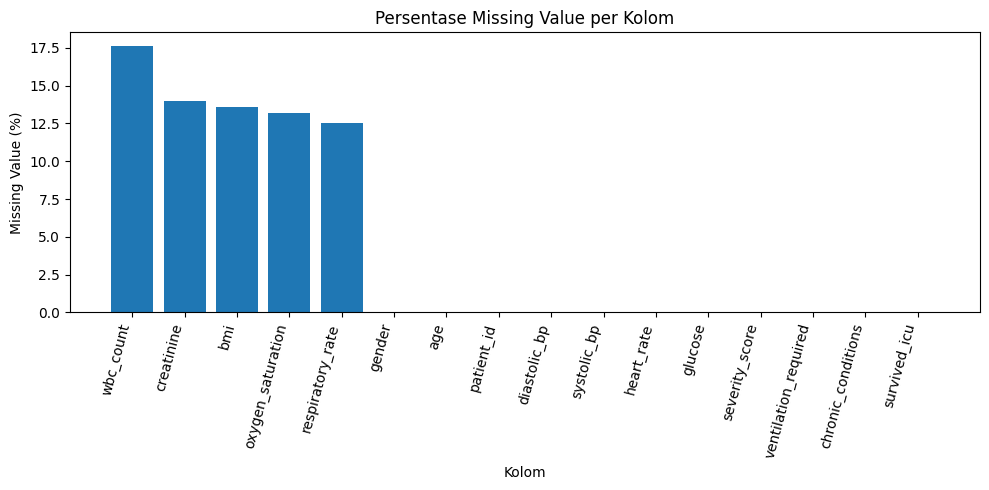

Jumlah baris yang memiliki minimal satu missing value: 808


In [9]:
missing_pct = df.isna().mean().mul(100).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(missing_pct.index, missing_pct.values)
plt.title("Persentase Missing Value per Kolom")
plt.xlabel("Kolom")
plt.ylabel("Missing Value (%)")
plt.xticks(rotation=75, ha="right")
plt.tight_layout()
plt.show()

print("Jumlah baris yang memiliki minimal satu missing value:",
      df.isna().any(axis=1).sum())

### 3.2 Duplicate

In [10]:
print("Duplicate seluruh kolom:", df.duplicated().sum())
print("Duplicate patient_id:", df["patient_id"].duplicated().sum())

tanpa_id = df.drop(columns=["patient_id"])
print("Baris yang terlibat duplicate berdasarkan fitur + target:",
      tanpa_id.duplicated(keep=False).sum())

Duplicate seluruh kolom: 0
Duplicate patient_id: 0
Baris yang terlibat duplicate berdasarkan fitur + target: 116


### 3.3 Outlier dan Boxplot

**Boxplot** digunakan untuk melihat sebaran data dan nilai yang jauh dari kelompok utama. Titik di luar whisker biasanya dianggap kandidat outlier secara statistik. Namun, outlier tidak otomatis salah; karena itu kita juga memakai pemeriksaan logis/domain.

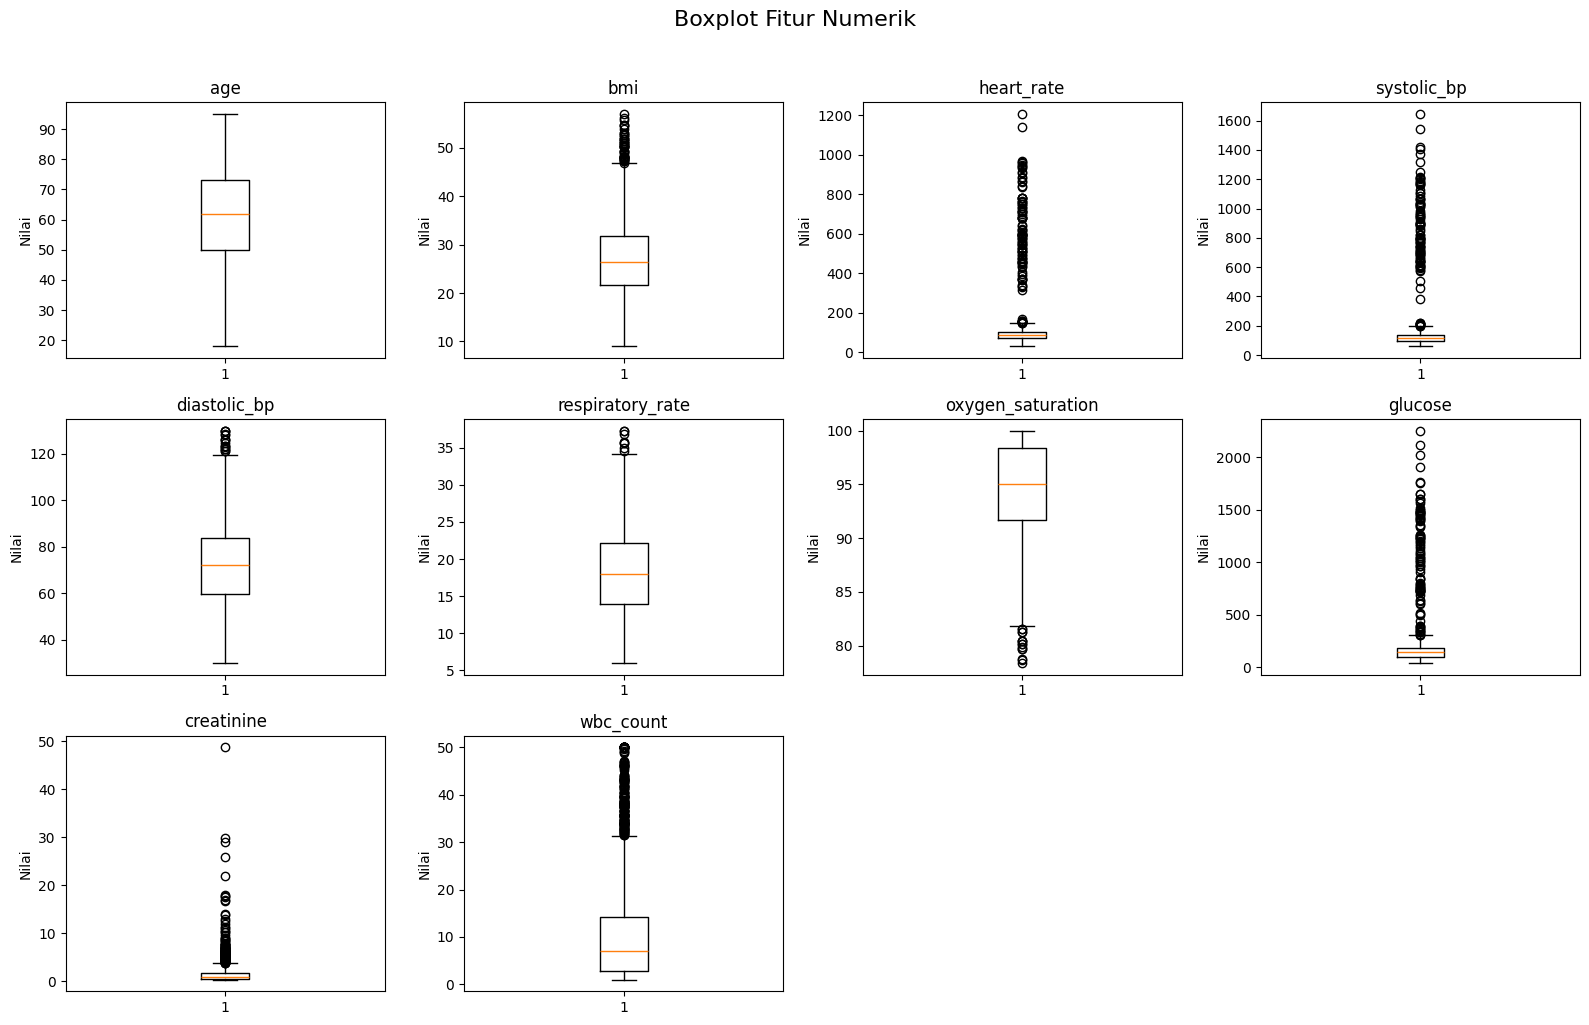

In [11]:
continuous_features = [
    "age", "bmi", "heart_rate", "systolic_bp", "diastolic_bp",
    "respiratory_rate", "oxygen_saturation", "glucose",
    "creatinine", "wbc_count"
]

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
for ax, col in zip(axes.ravel(), continuous_features):
    ax.boxplot(df[col].dropna())
    ax.set_title(col)
    ax.set_ylabel("Nilai")

for ax in axes.ravel()[len(continuous_features):]:
    ax.axis("off")

plt.suptitle("Boxplot Fitur Numerik", y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

### 3.4 Pemeriksaan Nilai Tidak Logis

Beberapa aturan sederhana digunakan untuk mencari noise, misalnya nilai fisiologis negatif, saturasi di atas 100%, atau tekanan sistolik lebih kecil daripada diastolik.

In [12]:
logical_check = {
    "age < 0": (df["age"] < 0).sum(),
    "bmi <= 0": (df["bmi"] <= 0).sum(),
    "heart_rate <= 0": (df["heart_rate"] <= 0).sum(),
    "systolic_bp <= 0": (df["systolic_bp"] <= 0).sum(),
    "diastolic_bp <= 0": (df["diastolic_bp"] <= 0).sum(),
    "systolic < diastolic": (df["systolic_bp"] < df["diastolic_bp"]).sum(),
    "respiratory_rate <= 0": (df["respiratory_rate"] <= 0).sum(),
    "oxygen_saturation di luar 0-100":
        ((df["oxygen_saturation"] < 0) | (df["oxygen_saturation"] > 100)).sum(),
    "glucose <= 0": (df["glucose"] <= 0).sum(),
    "creatinine < 0": (df["creatinine"] < 0).sum(),
    "wbc_count < 0": (df["wbc_count"] < 0).sum()
}

display(pd.Series(logical_check, name="jumlah"))

age < 0                              0
bmi <= 0                             0
heart_rate <= 0                      0
systolic_bp <= 0                     0
diastolic_bp <= 0                    0
systolic < diastolic               344
respiratory_rate <= 0                0
oxygen_saturation di luar 0-100      0
glucose <= 0                         0
creatinine < 0                       0
wbc_count < 0                        0
Name: jumlah, dtype: int64

### 3.5 Distribusi Data — Histogram

Histogram membantu melihat bentuk distribusi setiap fitur, misalnya apakah data terkonsentrasi pada rentang tertentu atau memiliki ekor panjang.

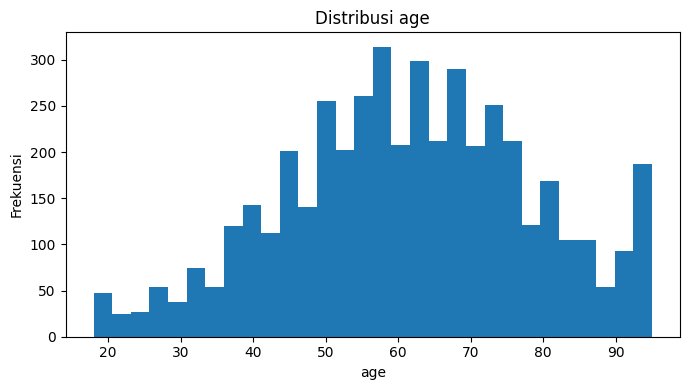

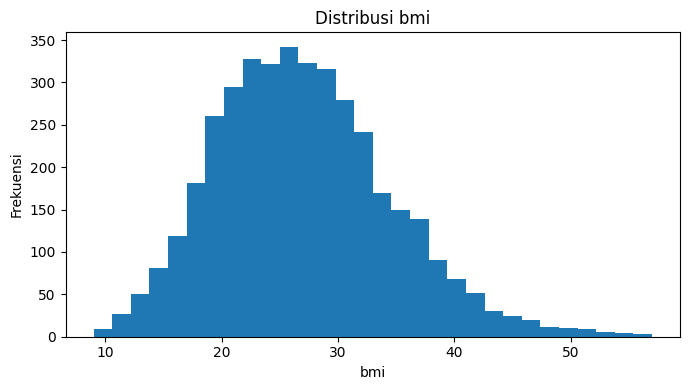

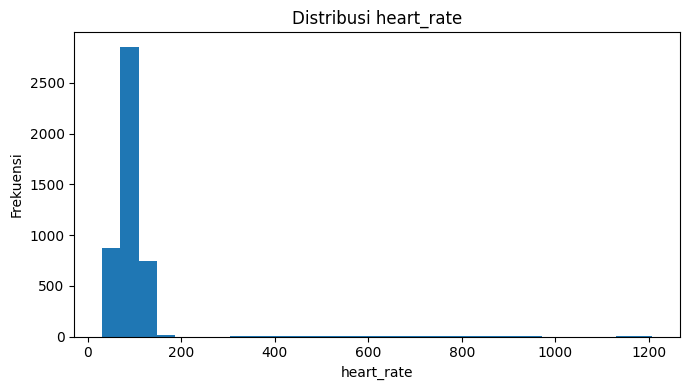

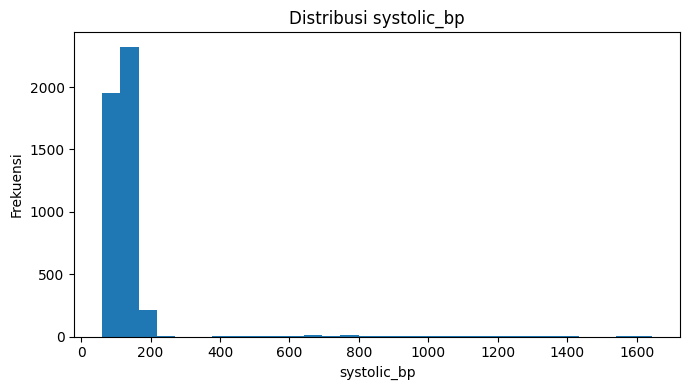

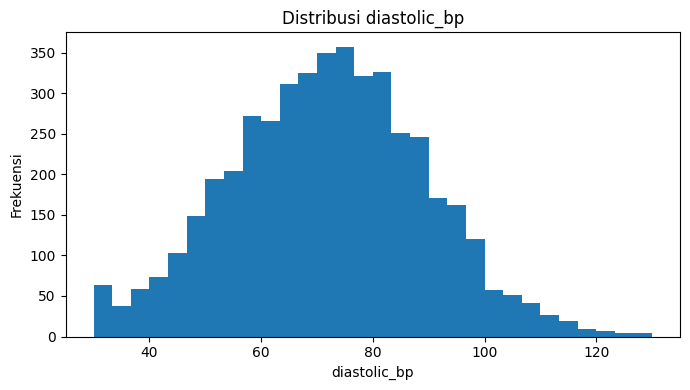

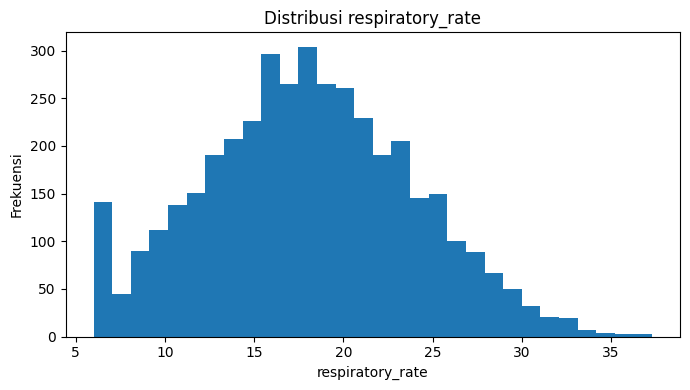

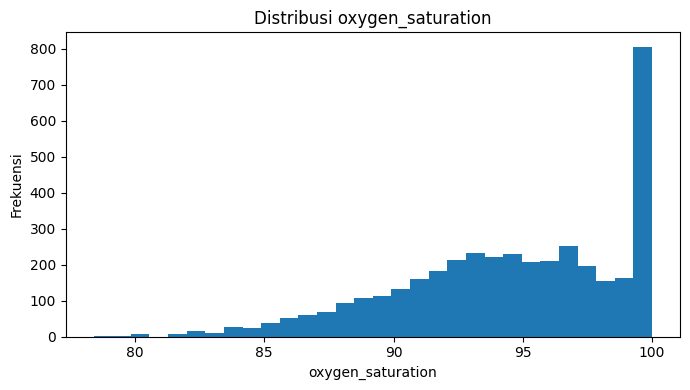

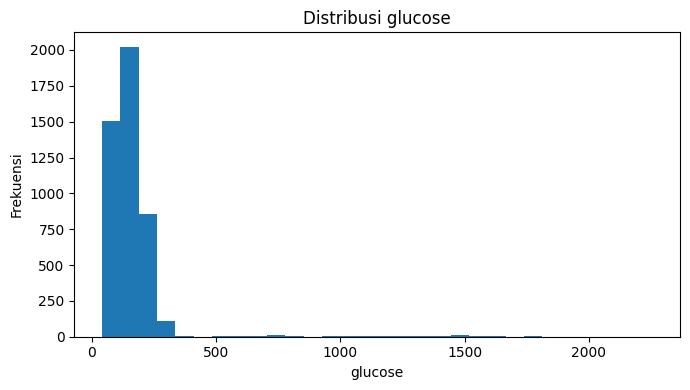

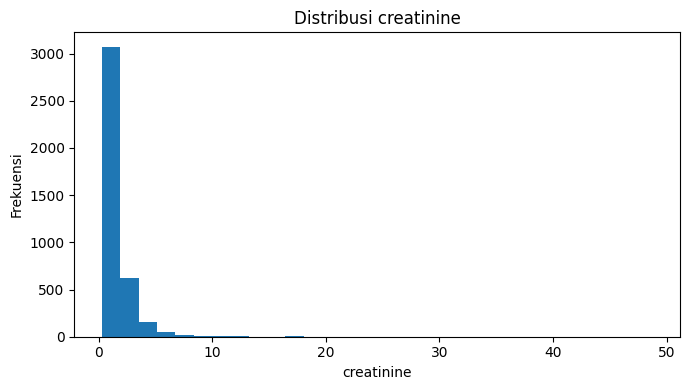

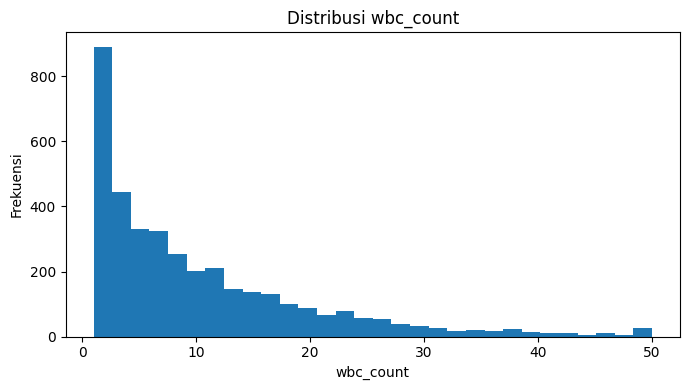

In [13]:
for col in continuous_features:
    plt.figure(figsize=(7, 4))
    plt.hist(df[col].dropna(), bins=30)
    plt.title(f"Distribusi {col}")
    plt.xlabel(col)
    plt.ylabel("Frekuensi")
    plt.tight_layout()
    plt.show()

## 4. Data Cleaning

Berdasarkan pemeriksaan sebelumnya, cleaning dilakukan dengan langkah sederhana:

1. Menghapus duplicate tambahan.
2. Menghapus baris yang jelas mengalami corrupted extreme values.
3. Memperbaiki kasus *systolic_bp < diastolic_bp* dengan menukar kedua nilai.
4. Missing value **tidak langsung dibuang**, tetapi akan ditangani dengan **median imputation** saat preprocessing model.

In [14]:
df_raw = df.copy()
df_clean = df.copy()

# 1. Hapus duplicate berdasarkan seluruh kolom selain patient_id.
non_id_cols = [c for c in df_clean.columns if c != "patient_id"]

duplicate_mask = df_clean.duplicated(
    subset=non_id_cols,
    keep="first"
)

n_removed_duplicate = duplicate_mask.sum()
df_clean = df_clean.loc[~duplicate_mask].copy()

print("Duplicate yang dibuang:", n_removed_duplicate)

Duplicate yang dibuang: 58


In [15]:
# 2. Hapus corrupted extreme rows.
# Berdasarkan pemeriksaan pada notebook basis:
# heart_rate > 250 dan systolic_bp > 300 dianggap corrupted extreme.

extreme_corrupt = (
    (df_clean["heart_rate"] > 250) &
    (df_clean["systolic_bp"] > 300)
)

n_removed_extreme = extreme_corrupt.sum()
df_clean = df_clean.loc[~extreme_corrupt].copy()

print("Corrupted extreme rows yang dibuang:", n_removed_extreme)

Corrupted extreme rows yang dibuang: 92


In [16]:
# 3. Perbaiki tekanan darah yang tidak konsisten.
bp_inconsistent = df_clean["systolic_bp"] < df_clean["diastolic_bp"]
n_bp_corrected = bp_inconsistent.sum()

systolic_lama = df_clean.loc[bp_inconsistent, "systolic_bp"].copy()

df_clean.loc[bp_inconsistent, "systolic_bp"] = (
    df_clean.loc[bp_inconsistent, "diastolic_bp"].values
)
df_clean.loc[bp_inconsistent, "diastolic_bp"] = systolic_lama.values

print("Baris dengan tekanan darah yang diperbaiki:", n_bp_corrected)
print("Systolic < diastolic setelah cleaning:",
      (df_clean["systolic_bp"] < df_clean["diastolic_bp"]).sum())

Baris dengan tekanan darah yang diperbaiki: 343
Systolic < diastolic setelah cleaning: 0


In [17]:
cleaning_log = pd.DataFrame({
    "proses": [
        "Data awal",
        "Hapus duplicate",
        "Hapus corrupted extreme",
        "Perbaiki systolic < diastolic",
        "Data akhir"
    ],
    "jumlah": [
        len(df_raw),
        n_removed_duplicate,
        n_removed_extreme,
        n_bp_corrected,
        len(df_clean)
    ],
    "jenis": [
        "jumlah baris",
        "baris dibuang",
        "baris dibuang",
        "baris diperbaiki",
        "jumlah baris"
    ]
})

display(cleaning_log)
print("Ukuran awal :", df_raw.shape)
print("Ukuran akhir:", df_clean.shape)

,proses,jumlah,jenis
0,Data awal,4580,jumlah baris
1,Hapus duplicate,58,baris dibuang
2,Hapus corrupted extreme,92,baris dibuang
3,Perbaiki systolic < diastolic,343,baris diperbaiki
4,Data akhir,4430,jumlah baris


Ukuran awal : (4580, 16)
Ukuran akhir: (4430, 16)


### 4.1 Cek Ulang Setelah Cleaning

In [18]:
print("Patient ID unik:", df_clean["patient_id"].is_unique)
print("Duplicate fitur + target:",
      df_clean.duplicated(subset=non_id_cols, keep=False).sum())
print("Corrupted extreme tersisa:",
      ((df_clean["heart_rate"] > 250) &
       (df_clean["systolic_bp"] > 300)).sum())
print("Systolic < diastolic:",
      (df_clean["systolic_bp"] < df_clean["diastolic_bp"]).sum())

Patient ID unik: True
Duplicate fitur + target: 0
Corrupted extreme tersisa: 0
Systolic < diastolic: 0


### 4.2 Heatmap Korelasi

Heatmap digunakan untuk melihat hubungan antarvariabel numerik. Nilai mendekati **+1** berarti hubungan positif kuat, mendekati **-1** berarti hubungan negatif kuat, dan mendekati **0** berarti hubungan linear monoton yang lemah.

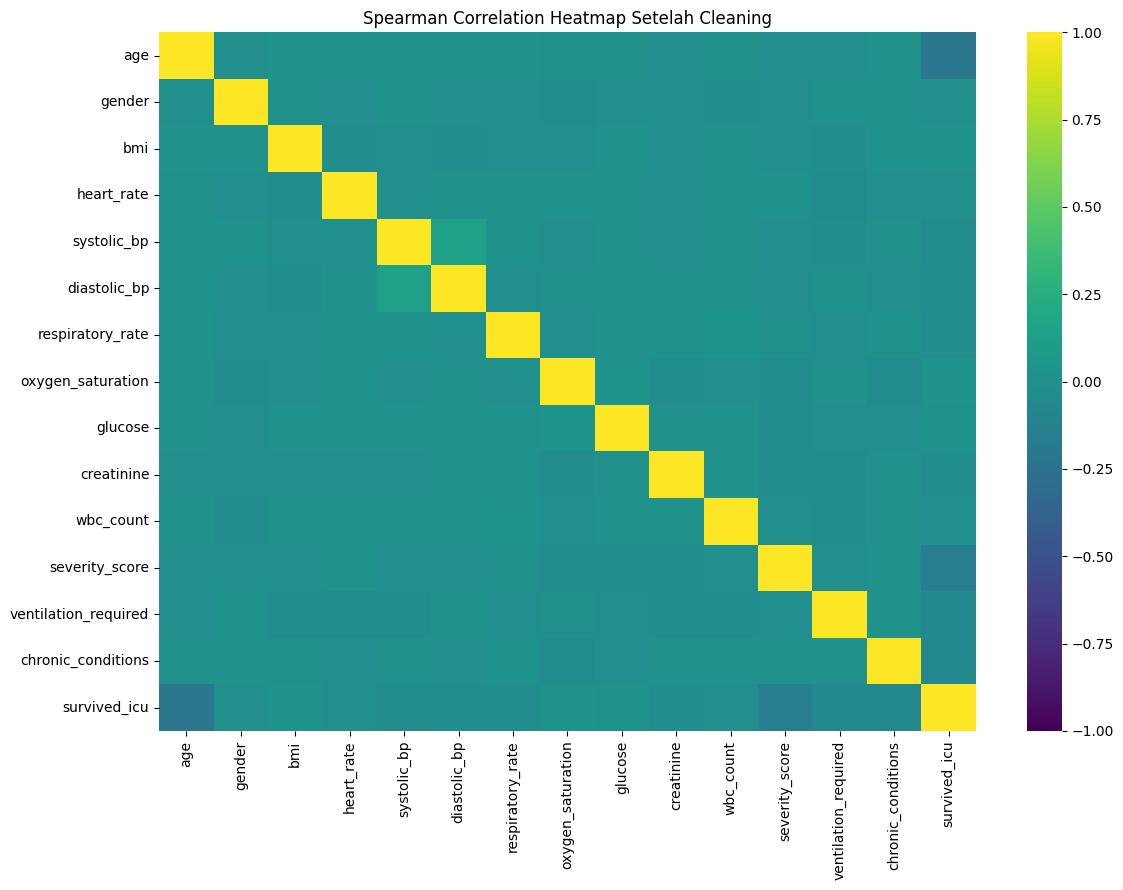

In [19]:
numeric_cols = df_clean.select_dtypes(include="number").columns
corr_spearman = df_clean[numeric_cols].corr(method="spearman")

plt.figure(figsize=(12, 9))
sns.heatmap(
    corr_spearman,
    cmap="viridis",
    vmin=-1,
    vmax=1,
    annot=False
)
plt.title("Spearman Correlation Heatmap Setelah Cleaning")
plt.tight_layout()
plt.show()

In [20]:
corr_target = (
    corr_spearman["survived_icu"]
    .drop("survived_icu")
    .sort_values(key=abs, ascending=False)
)

display(
    corr_target.to_frame("Spearman_Correlation").round(3)
)

,Spearman_Correlation
age,-0.206
severity_score,-0.153
ventilation_required,-0.062
chronic_conditions,-0.057
systolic_bp,-0.038
oxygen_saturation,0.031
diastolic_bp,-0.031
bmi,0.028
creatinine,-0.028
respiratory_rate,-0.018


## 5. Supervised Learning

**Supervised learning** adalah pembelajaran mesin menggunakan data yang sudah mempunyai **label/target**.

Pada kasus ini:

- **Input (X):** karakteristik pasien ICU.
- **Target (y):** **survived_icu**.
- Model belajar hubungan X → y dari data training.
- Setelah belajar, model diuji pada data testing yang tidak digunakan saat training.

Karena target hanya memiliki dua kelas (0 dan 1), kita menggunakan **klasifikasi biner**.

### 5.1 Menentukan X dan y + Train-Test Split

Data dibagi menjadi training dan testing sebelum preprocessing yang mempelajari parameter dari data. Ini dilakukan untuk menghindari **data leakage**.

In [21]:
X = df_clean.drop(columns=["patient_id", "survived_icu"])
y = df_clean["survived_icu"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Data training:", X_train.shape)
print("Data testing :", X_test.shape)

print("\nDistribusi target training:")
display(y_train.value_counts(normalize=True).mul(100).round(2))

print("\nDistribusi target testing:")
display(y_test.value_counts(normalize=True).mul(100).round(2))

Data training: (3544, 14)
Data testing : (886, 14)

Distribusi target training:


survived_icu
1    64.53
0    35.47
Name: proportion, dtype: float64


Distribusi target testing:


survived_icu
1    64.56
0    35.44
Name: proportion, dtype: float64

### 5.2 Preprocessing untuk Logistic Regression

Langkah preprocessing yang dipakai sengaja sederhana:

1. **Median imputation** → mengisi missing value numerik dengan nilai tengah.
2. **StandardScaler** → menyamakan skala fitur agar fitur dengan rentang besar tidak mendominasi proses optimasi.
3. **Logistic Regression** → model klasifikasi biner.

Semua langkah dimasukkan ke dalam **Pipeline** supaya preprocessing training dan testing konsisten serta mengurangi risiko data leakage.

In [22]:
numeric_features = X_train.columns.tolist()

model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("logistic_regression", LogisticRegression(
        max_iter=2000,
        random_state=RANDOM_STATE
    ))
])

model.fit(X_train, y_train)

print("Model Logistic Regression berhasil dilatih.")

Model Logistic Regression berhasil dilatih.


### 5.3 Prediksi

In [23]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print("10 hasil prediksi pertama:")
display(pd.DataFrame({
    "Aktual": y_test.iloc[:10].values,
    "Prediksi": y_pred[:10],
    "Probabilitas_survive": np.round(y_proba[:10], 3)
}))

10 hasil prediksi pertama:


,Aktual,Prediksi,Probabilitas_survive
0,0,0,0.418
1,1,1,0.899
2,0,1,0.596
3,1,1,0.654
4,1,1,0.661
5,1,1,0.918
6,1,1,0.778
7,0,1,0.543
8,1,1,0.592
9,0,1,0.690


## 6. Evaluasi Model

Beberapa metrik digunakan agar performa tidak hanya dilihat dari accuracy:

- **Accuracy:** proporsi prediksi yang benar dari seluruh data.
- **Precision:** dari semua yang diprediksi selamat, berapa yang benar-benar selamat.
- **Recall:** dari semua pasien yang benar-benar selamat, berapa yang berhasil dikenali model.
- **F1-score:** keseimbangan antara precision dan recall.
- **ROC-AUC:** kemampuan model membedakan dua kelas berdasarkan probabilitas prediksi.

Untuk tugas klasifikasi biner, melihat beberapa metrik lebih informatif daripada hanya accuracy.

In [24]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
roc_auc = roc_auc_score(y_test, y_proba)

results = pd.DataFrame({
    "Metrik": ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"],
    "Nilai": [accuracy, precision, recall, f1, roc_auc]
})

display(results.round(4))

,Metrik,Nilai
0,Accuracy,0.6512
1,Precision,0.6824
2,Recall,0.8601
3,F1-Score,0.7610
4,ROC-AUC,0.6373


### 6.1 Classification Report

In [25]:
print(classification_report(
    y_test,
    y_pred,
    target_names=["Tidak Selamat (0)", "Selamat (1)"],
    zero_division=0
))

                   precision    recall  f1-score   support

Tidak Selamat (0)       0.52      0.27      0.35       314
      Selamat (1)       0.68      0.86      0.76       572

         accuracy                           0.65       886
        macro avg       0.60      0.57      0.56       886
     weighted avg       0.62      0.65      0.62       886



### 6.2 Confusion Matrix

Confusion matrix menunjukkan jumlah prediksi yang benar dan salah untuk masing-masing kelas.

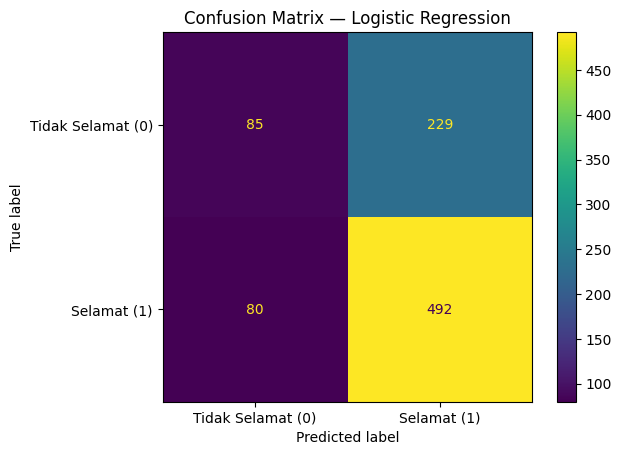

In [26]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Tidak Selamat (0)", "Selamat (1)"]
)

disp.plot()
plt.title("Confusion Matrix — Logistic Regression")
plt.show()

### 6.3 ROC Curve

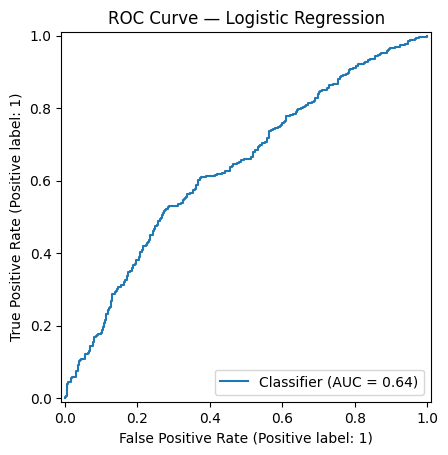

In [27]:
RocCurveDisplay.from_predictions(y_test, y_proba)
plt.title("ROC Curve — Logistic Regression")
plt.show()

## 7. Interpretasi Koefisien Logistic Regression

Logistic Regression menghasilkan **koefisien** untuk setiap fitur.

- Koefisien **positif** → kenaikan fitur cenderung meningkatkan peluang kelas 1 (**survived_icu = 1**).
- Koefisien **negatif** → kenaikan fitur cenderung menurunkan peluang kelas 1.
- Semakin besar nilai absolut koefisien, semakin kuat pengaruh linear fitur terhadap log-odds target, dengan asumsi fitur lain tetap.

Karena fitur sudah di-**StandardScaler**, besar koefisien dapat dibandingkan dengan lebih masuk akal antarfitur.

In [28]:
lr = model.named_steps["logistic_regression"]

coef = pd.Series(
    lr.coef_[0],
    index=numeric_features
).sort_values()

coef_table = pd.DataFrame({
    "Fitur": coef.index,
    "Koefisien": coef.values,
    "Arah": np.where(coef.values > 0, "Positif", "Negatif")
})

display(coef_table.round(4))

,Fitur,Koefisien,Arah
0,age,-0.4992,Negatif
1,severity_score,-0.3830,Negatif
2,ventilation_required,-0.1507,Negatif
3,chronic_conditions,-0.1442,Negatif
4,creatinine,-0.0859,Negatif
5,systolic_bp,-0.0575,Negatif
6,respiratory_rate,-0.0505,Negatif
7,heart_rate,-0.0361,Negatif
8,diastolic_bp,-0.0324,Negatif
9,wbc_count,-0.0266,Negatif


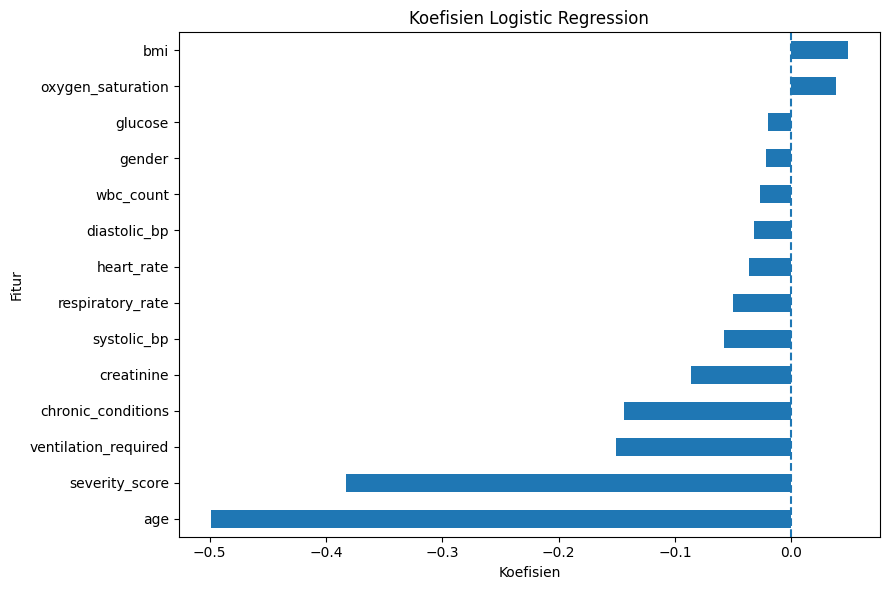

In [29]:
plt.figure(figsize=(9, 6))
coef.sort_values().plot(kind="barh")
plt.axvline(0, linestyle="--")
plt.title("Koefisien Logistic Regression")
plt.xlabel("Koefisien")
plt.ylabel("Fitur")
plt.tight_layout()
plt.show()

### 7.1 Interpretasi Praktis

Interpretasi berikut dibaca dari tanda dan besar koefisien, bukan sebagai hubungan sebab-akibat. Model hanya menemukan pola prediktif pada data.

- Fitur dengan koefisien positif cenderung berkaitan dengan probabilitas **survived_icu = 1** yang lebih tinggi.
- Fitur dengan koefisien negatif cenderung berkaitan dengan probabilitas **survived_icu = 1** yang lebih rendah.
- Fitur dengan koefisien mendekati nol memberikan kontribusi linear yang relatif kecil dalam model.
- **Koefisien bukan bukti bahwa suatu fitur menyebabkan pasien selamat atau tidak selamat.** Ini adalah hubungan prediktif dalam model.

Untuk laporan, gunakan nilai koefisien yang muncul dari output notebook setelah dijalankan sebagai dasar menyebut fitur paling positif dan paling negatif.

In [30]:
top_positive = coef.sort_values(ascending=False).head(5)
top_negative = coef.sort_values().head(5)

print("5 fitur dengan koefisien paling positif:")
display(top_positive.to_frame("Koefisien").round(4))

print("\n5 fitur dengan koefisien paling negatif:")
display(top_negative.to_frame("Koefisien").round(4))

5 fitur dengan koefisien paling positif:


,Koefisien
bmi,0.0488
oxygen_saturation,0.0384
glucose,-0.0203
gender,-0.0216
wbc_count,-0.0266



5 fitur dengan koefisien paling negatif:


,Koefisien
age,-0.4992
severity_score,-0.3830
ventilation_required,-0.1507
chronic_conditions,-0.1442
creatinine,-0.0859


## 8. Perbandingan Sebelum dan Sesudah Preprocessing

Sebagai pembanding sederhana, model baseline hanya melakukan **median imputation**, sedangkan model akhir melakukan **median imputation + StandardScaler**.

Perbandingan ini membantu menunjukkan apakah preprocessing yang digunakan memberikan perubahan performa.

In [31]:
baseline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("logistic_regression", LogisticRegression(
        max_iter=2000,
        random_state=RANDOM_STATE
    ))
])

baseline.fit(X_train, y_train)
baseline_pred = baseline.predict(X_test)
baseline_proba = baseline.predict_proba(X_test)[:, 1]

comparison = pd.DataFrame({
    "Model": ["Baseline", "Logistic Regression + Scaling"],
    "Accuracy": [
        accuracy_score(y_test, baseline_pred),
        accuracy_score(y_test, y_pred)
    ],
    "Precision": [
        precision_score(y_test, baseline_pred, zero_division=0),
        precision
    ],
    "Recall": [
        recall_score(y_test, baseline_pred, zero_division=0),
        recall
    ],
    "F1": [
        f1_score(y_test, baseline_pred, zero_division=0),
        f1
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, baseline_proba),
        roc_auc
    ]
})

display(comparison.round(4))

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Baseline,0.6512,0.6824,0.8601,0.761,0.6371
1,Logistic Regression + Scaling,0.6512,0.6824,0.8601,0.761,0.6373


## 9. Kesimpulan

### Temuan Data
Dataset ICU memiliki beberapa masalah kualitas data, terutama **missing value, duplicate, nilai ekstrem/corrupted, outlier, dan inkonsistensi tekanan darah**. Masalah tersebut diperiksa terlebih dahulu sebelum modeling.

### Preprocessing
Cleaning dilakukan dengan membuang duplicate dan corrupted extreme rows serta memperbaiki ketidakkonsistenan tekanan darah. Missing value tidak dibuang seluruhnya karena dapat mengurangi jumlah data; sebagai gantinya, model menggunakan **median imputation**.

### Visualisasi
- **Histogram** digunakan untuk melihat distribusi masing-masing fitur.
- **Boxplot** digunakan untuk mendeteksi kandidat outlier.
- **Heatmap** digunakan untuk melihat korelasi antarvariabel.

### Supervised Learning
Karena target **survived_icu** adalah biner, masalah ini merupakan **binary classification**. Model yang digunakan adalah **Logistic Regression**.

### Interpretasi Model
Koefisien Logistic Regression menunjukkan arah hubungan prediktif setiap fitur terhadap peluang **survived_icu = 1**. Koefisien positif menunjukkan arah positif, sedangkan koefisien negatif menunjukkan arah negatif. Interpretasi harus dibaca sebagai **hubungan prediktif**, bukan hubungan sebab-akibat.

### Evaluasi
Performa model dinilai menggunakan **Accuracy, Precision, Recall, F1-Score, ROC-AUC, confusion matrix, dan ROC curve**. Nilai aktual mengikuti output saat notebook dijalankan.

## 10. Ringkasan Alur

```text
Dataset ICU
    ↓
Data Understanding
    ↓
Cek kolom + missing + duplicate + outlier + consistency
    ↓
Data Cleaning
    ↓
Histogram + Boxplot + Heatmap
    ↓
Pisahkan X dan y
    ↓
Train-Test Split
    ↓
Median Imputation
    ↓
Standard Scaling
    ↓
Logistic Regression
    ↓
Prediksi
    ↓
Evaluasi
    ↓
Interpretasi koefisien
```

**Inti tugas:** data yang kotor dibersihkan dan dipersiapkan terlebih dahulu, kemudian digunakan untuk supervised learning dengan Logistic Regression.